<a href="https://colab.research.google.com/github/atharvabhairam/3-Column-Preview-Card-Component/blob/main/01_pytorch_workflow_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import torch
from torch import nn
import matplotlib.pyplot as plt


torch.__version__

'2.9.0+cpu'

In [ ]:
#weight,bias
weight=0.7
bias=0.3


start=0
end=1
step=0.02
x=torch.arange(start, end, step).unsqueeze(dim=1)
y=weight*x+bias
x[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
len(x),len(y)

(50, 50)

###Spliting data into training and test sets (one of the most important concepts in machine learning in general.)

##Let's create a training and test set with our data.


In [ ]:
#import
train_split=int(0.8*len(x))
x_train, y_train =x[:train_split],y[:train_split]
x_test, y_test=x[train_split:],y[train_split:]
len(x_train),len(y_train), len(x_test), len(y_test)

(40, 40, 10, 10)

In [ ]:
import matplotlib.pyplot as plt

def plot_predictions(train_data=x_train,
                     train_labels=y_train,
                     test_data=x_test,
                     test_labels=y_test,
                     predictions=None):

    plt.figure(figsize=(10, 7))
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    plt.scatter(test_data, test_labels, c="g", s=4, label="Test data")

    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    plt.legend(prop={"size": 14})




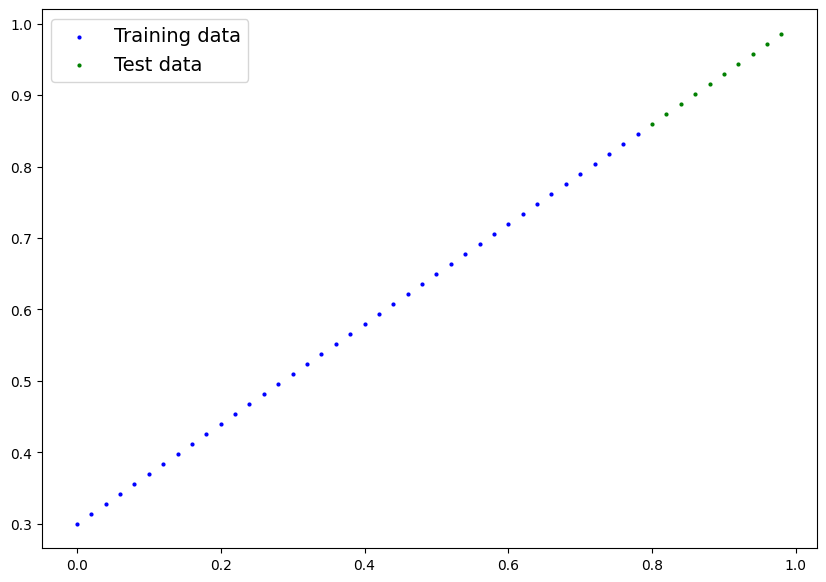

In [ ]:
plot_predictions();

##2. Build model

Our PyTorch model!

This is very exciting... let's do it!

In [ ]:

class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights= nn.Parameter(torch.rand(1,
                                          requires_grad=True,
                                          dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))

  def forward(self, x:torch.Tensor)-> torch.Tensor:
    return self.weights*x+self.bias




##Checking the contents of our PyTorch model
Now we have created a model,let's see what's inside
So we can check our model parameters or what's inside our model using `.parameters`


In [ ]:

torch.manual_seed(42)


model_0=LinearRegressionModel()


list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([-0.6382], requires_grad=True)]

In [ ]:

model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([-0.6382]))])

###Making prediction using `torch.inference_model()`

To check our model's predictive power, let's see how well it predicts 'y_test' based on 'x_test'.

When we pass data through our model, it's going to run it through the forward() method.

In [ ]:
x_test, y_test

NameError: name 'x_test' is not defined

In [ ]:

with torch.inference_mode():
  y_preds=model_0(x_test)
y_preds


In [ ]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])